# Salmonellosis Trend Analysis

A data analysis project exploring Salmonellosis notification trends across NSW, VIC and QLD (2018–2023). This was an introductory project undertaken to learn matplotlib and pandas, using a publicly available health dataset. After noticing an unusual dip in Victorian cases around 2020–2021, QLD was added as a comparison state given its significantly lighter lockdown restrictions relative to VIC. NSW was included as an additional reference point.

The visual suggests a possible correlation between lockdown stringency and reduced Salmonellosis incidence, potentially due to reduced social mixing and food handling outside the home. However, further investigation would be needed to establish any causal relationship, as other confounding factors, such as changes in healthcare-seeking behaviour and reporting rates during the pandemic, may also contribute to the observed trends.

*Note: This is an early exploratory project and is not intended as a complete or rigorous analysis. It is included here as a record of initial data exploration and learning.*

## 1. Install & Import Libraries


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

## 2. Load & Clean Data

In [6]:
# Load dataset
df = pd.read_csv("nndss-public-dataset-salmonella.csv")

# Strip whitespace from column names
df.rename(columns=lambda c: c.strip(), inplace=True)

# Parse date column and extract year
date_col = "Week ending (Friday)"
df[date_col] = pd.to_datetime(df[date_col], dayfirst=True, errors="coerce")
df["Year"] = df[date_col].dt.year

# Normalise state names to uppercase
df["State"] = df["State"].str.upper()

## 3. Aggregate to Monthly Counts

In [8]:
# Count cases per week per state
weekly_counts = (
    df.groupby(["Week ending (Friday)", "State"])
    .size()
    .reset_index(name="Cases")
)

# Convert weekly dates to monthly periods for smoother visualisation
weekly_counts["Month"] = weekly_counts[date_col].dt.to_period("M").dt.to_timestamp()
weekly_counts["Year"] = weekly_counts[date_col].dt.year

# Aggregate to monthly counts per state
monthly_counts = (
    weekly_counts.groupby(["Month", "State"])["Cases"]
    .sum()
    .reset_index()
)

# Filter to 2018-2023 analysis period
monthly_counts = monthly_counts[
    (monthly_counts["Month"].dt.year >= 2018) &
    (monthly_counts["Month"].dt.year <= 2023)
]

## 4. Visualise Results


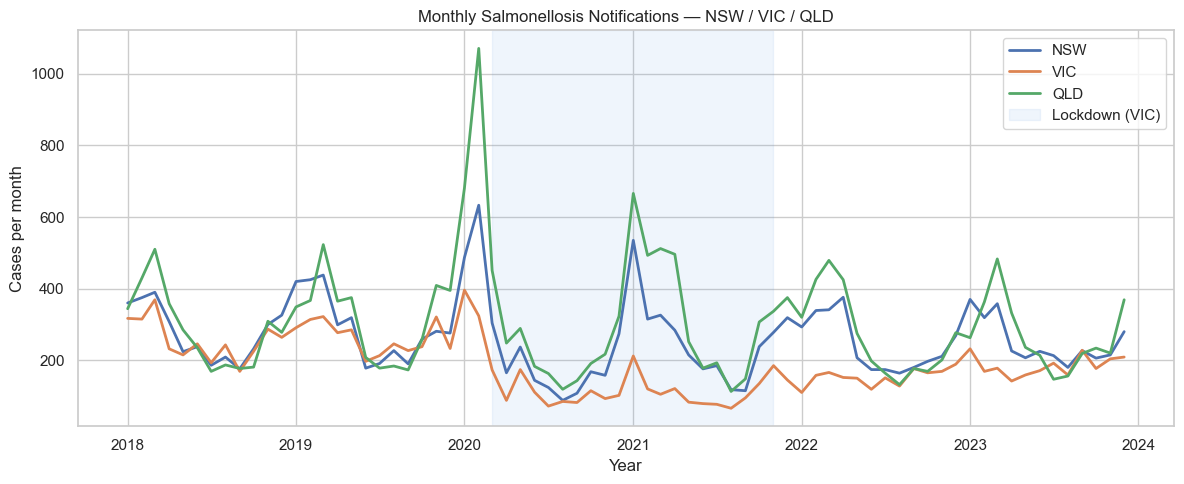

In [10]:
plt.figure(figsize=(12, 5))

# Plot monthly cases for each state
for state in ["NSW", "VIC", "QLD"]:
    state_data = monthly_counts[monthly_counts["State"] == state]
    plt.plot(state_data["Month"], state_data["Cases"], linewidth=2, label=state)

# Shade VIC lockdown period for context
lockdown_start = pd.to_datetime("2020-03-01")
lockdown_end = pd.to_datetime("2021-10-31")
plt.axvspan(lockdown_start, lockdown_end, color='#679ee6', alpha=0.1, label="Lockdown (VIC)")

# Set yearly x-axis ticks for readability
years = list(range(2018, 2025))
plt.xticks(
    [pd.Timestamp(f"{year}-01-01") for year in years],
    [str(year) for year in years]
)

plt.title("Monthly Salmonellosis Notifications — NSW / VIC / QLD")
plt.xlabel("Year")
plt.ylabel("Cases per month")
plt.legend()
plt.tight_layout()
plt.show()